# Assignment - A02 Gradient Descent (30 ⭕️s)

**Jonah Ebent**


## Overview


In this assignment, you will implement gradient descent to *train* a linear regression model.

You will:
- Reuse the model $f_{w,b}(x) = wx + b$.
- Reuse the Mean Squared Error cost function $J(w,b)$ **from class** that you coded for A01 (correct it if needed).
- Compute the gradients $\frac{\partial J}{\partial w}$ and $\frac{\partial J}{\partial b}$.
- Implement gradient descent to automatically improve $w$ and $b$.
- Experiment with different learning rates to see what changes.


### Notation

|General Notation | Description | Python (if applicable) |
|------------|-------------|----|
| $a$ | scalar, non bold      | |
| $\mathbf{a}$ | vector, bold  | |
| **Regression** |         |    |     |
| $\mathbf{x}$ | Training item feature values (in this case - Size (1000 sqft))  | `x_train` |
| $\mathbf{y}$ | Training item targets (in this case Price (1000s of dollars)) | `y_train` |
| $w$ | weight (slope) | `w` |
| $b$ | bias (y-intercept) | `b` |
| $\alpha$ | learning rate (step size) | `alpha` |
| $m$ | number of training examples | `m` |
| $J(w,b)$ | cost function (MSE variant) | `compute_cost(...)` |
| $\frac{\partial J}{\partial w}$ | gradient for $w$ | `dj_dw` |
| $\frac{\partial J}{\partial b}$ | gradient for $b$ | `dj_db` |


### Problem Statement

A real estate agency wants you to find a function to predict housing prices.

In A01, you tried different values of $w$ and $b$ by hand.
In this assignment, you will write code that updates $w$ and $b$ automatically.

You will train the model by minimizing the cost function using gradient descent.


## Example Code. Loading a dataset.
Run the following code cells to create example `x_train` and `y_train` variables. The data is stored in one-dimensional NumPy arrays.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# x_train is the input variable (size in 1000 square feet)
# y_train is the target (price in 1000s of dollars)
x_train = np.array([
    0.7, 0.8, 0.9, 1.0, 1.1,
    1.2, 1.3, 1.4, 1.5, 1.6,
    1.7, 1.8, 1.9, 2.0, 2.1,
    2.2, 2.3, 2.4, 2.5, 2.6
])

y_train = np.array([
    235.0, 260.0, 255.0, 290.0, 295.0,
    330.0, 325.0, 355.0, 350.0, 390.0,
    405.0, 410.0, 435.0, 440.0, 475.0,
    485.0, 510.0, 515.0, 550.0, 560.0
])
print(f"x_train = {x_train}")
print(f"y_train = {y_train}")


x_train = [0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4
 2.5 2.6]
y_train = [235. 260. 255. 290. 295. 330. 325. 355. 350. 390. 405. 410. 435. 440.
 475. 485. 510. 515. 550. 560.]


### Number of training examples `m`


In [3]:
print(f"x_train.shape: {x_train.shape}")
m = x_train.shape[0]
print(f"Number of training examples is: {m}")


x_train.shape: (20,)
Number of training examples is: 20


## Plotting the dataset
You will reuse this plot later to compare the model before and after training.


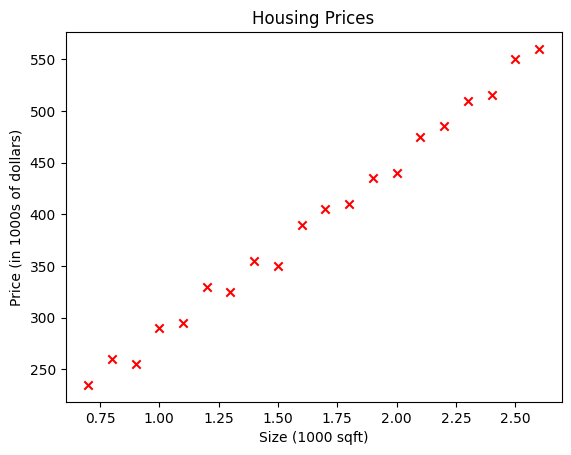

In [4]:
plt.scatter(x_train, y_train, marker='x', c='r')
plt.title("Housing Prices")
plt.ylabel('Price (in 1000s of dollars)')
plt.xlabel('Size (1000 sqft)')
plt.show()


## Model Function

Below is the same model output function from A01. It computes predictions for every value in `x`.


In [5]:
def compute_model_output(x, w, b):
    """
    Computes the prediction of a linear model
    Args:
      x (ndarray (m,)): Data, m examples in a one-dimensional array
      w,b (scalar)    : model parameters
    Returns
      f_wb (ndarray (m,)): model prediction
    """
    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = w * x[i] + b

    return f_wb


In [6]:
# Example for initial values of w and b
w = 0
b = 400

print(f"w: {w}")
print(f"b: {b}")


w: 0
b: 400


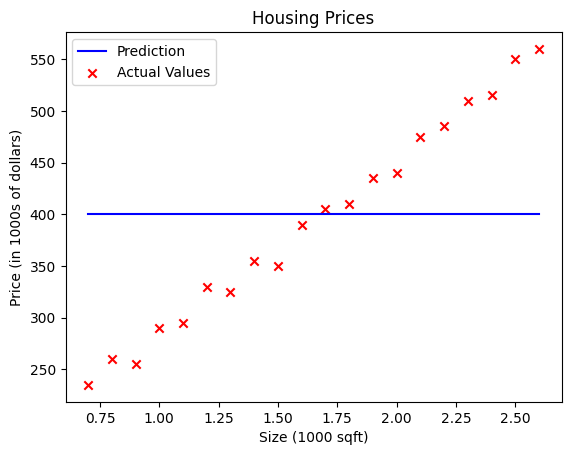

In [7]:
# Compute the model output for all x_train examples
tmp_f_wb = compute_model_output(x_train, w, b)

# Plot your model prediction
plt.plot(x_train, tmp_f_wb, c='b', label='Prediction')

# Plot the data points
plt.scatter(x_train, y_train, marker='x', c='r', label='Actual Values')

plt.title("Housing Prices")
plt.ylabel('Price (in 1000s of dollars)')
plt.xlabel('Size (1000 sqft)')
plt.legend()
plt.show()


### Task 1. Cost function
Code a function that inputs the dataset and calculates the mean squared error style cost function covered in lecture.
You can copy your implementation from A01.

⭕️⭕️

Print the value of the cost function for the poor fit above.

⭕️


In [8]:
# Mean Squared Error style Cost Function
def mean_squared_error(y, y_hat):
  assert len(y_hat) == len(y)
  m = len(y)
  return sum((y_hat - y) ** 2) / (2 * m)

def compute_cost(x, y, w, b):
    """
    Computes the cost function for linear regression
    Args:
      x (ndarray (m,)): Data, m examples in a one-dimensional array
      y (ndarray (m,)): target values
      w,b (scalar)    : model parameters
    Returns
      total_cost (scalar): the cost
    """
    assert(len(x) == len(y))
    y_hat = compute_model_output(x, w, b)
    return mean_squared_error(y, y_hat)


In [9]:
poor_w = w
poor_b = b
poor_cost = compute_cost(x_train, y_train, poor_w, poor_b)
print(f'Cost of poor fit function: {poor_cost}')


Cost of poor fit function: 4883.75


### Task 2. Gradients
Gradient descent needs the gradients (partial derivatives) of the cost function.

You will code a function that returns the two values:

$\frac{\partial J}{\partial w}$ and $\frac{\partial J}{\partial b}$

⭕️⭕️

Use your function to compute the gradients for the poor fit above and print them.

⭕️


In [10]:
def compute_gradient(x, y, w, b):
    """
    Computes the gradient for linear regression
    Args:
      x (ndarray (m,)): Data, m examples in a one-dimensional array
      y (ndarray (m,)): target values
      w,b (scalar)    : model parameters
    Returns
      dj_dw (scalar): The gradient of the cost w.r.t. the parameters w
      dj_db (scalar): The gradient of the cost w.r.t. the parameter b
    """
    assert(len(x) == len(y))
    m = len(x)
    # TODO name this variable better
    foo = w * x + b - y
    dj_dw = sum(foo * x) / m
    dj_db = sum(foo) / m
    return dj_dw, dj_db


In [11]:
dj_dw, dj_db = compute_gradient(x_train, y_train, w, b)
print(f'dj_dw: {dj_dw}')
print(f'dj_db: {dj_db}')


dj_dw: -45.925
dj_db: 6.5


### Task 3. Gradient Descent
Code a function that runs gradient descent for a fixed number of iterations.

At each iteration:
1. Compute the gradients
2. Update $w$ and $b$ using the learning rate $\alpha$
3. Save the cost value in a list so you can plot it later

⭕️⭕️⭕️⭕️

Print your final trained values of $w$ and $b$.

⭕️⭕️


In [12]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters):
    """
    Performs gradient descent to fit w,b.
    Args:
      x (ndarray (m,)): Data, m examples
      y (ndarray (m,)): target values
      w_in,b_in (scalar): initial values of model parameters
      alpha (float): learning rate
      num_iters (int): number of iterations to run gradient descent
    Returns:
      w (scalar): updated value of parameter w
      b (scalar): updated value of parameter b
      J_history (list): cost values over iterations
    """
    assert len(x) == len(y)
    w, b = w_in, b_in
    J_history = []
    for _ in range(num_iters):
      cost = compute_cost(x, y, w, b)
      J_history.append(cost)
      dj_dw, dj_db = compute_gradient(x_train, y_train, w, b)
      w = w - alpha * dj_dw
      b = b - alpha * dj_db
    return w, b, J_history

In [13]:
w_init = 0
b_init = 400
alpha = 0.01
iterations = 1000

print(f'w_init: {w_init}')
print(f'b_init: {b_init}')
print(f'Initial cost: {compute_cost(x_train, y_train, w_init, b_init)}')
print()

w_final, b_final, costs = gradient_descent(x_train, y_train, w_init, b_init, alpha, iterations)
print(f'w_final: {w_final}')
print(f'b_final: {b_final}')
print(f'Final cost: {costs[-1]}')

w_init: 0
b_init: 400
Initial cost: 4883.75

w_final: 100.17135059319297
b_final: 238.8021541799115
Final cost: 913.6078935832286


### Task 4 - Plot the Cost over Iterations
Plot the cost function value over the iterations of gradient descent.
You might need to edit your code to save the cost values at each iteration.

- Code the new function or the modified version of your gradient descent function to do the training and also make the plot of cost vs. iterations.

⭕️⭕️⭕️⭕️

- Produce the plot for the training from task 3.

⭕️⭕️

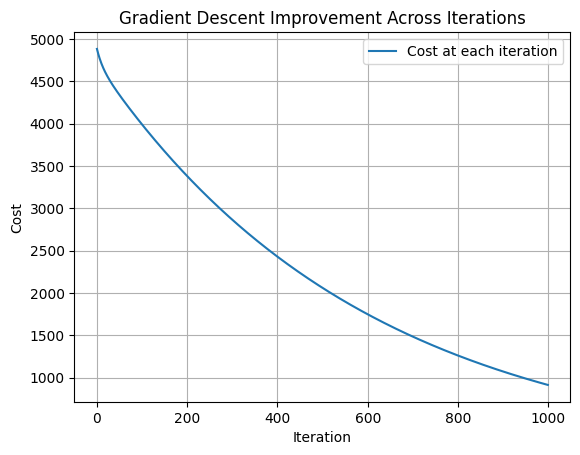

In [14]:
def gradient_descent_with_plot(x, y, w_in, b_in, alpha, num_iters, fileName=None):
  _, __, costs = gradient_descent(x, y, w_in, b_in, alpha, num_iters)
  plt.plot(range(num_iters), costs, label='Cost at each iteration')
  plt.title('Gradient Descent Improvement Across Iterations')
  plt.xlabel('Iteration')
  plt.ylabel('Cost')
  plt.grid()
  plt.legend()
  if fileName != None: plt.savefig(fileName)
  plt.show()

gradient_descent_with_plot(x_train, y_train, w_init, b_init, alpha, iterations)

### Task 5. Learning Rate Experiment
Run gradient descent using at least three different learning rates vary them by at least a factor of 5.

⭕️⭕️

Make a plot of cost vs iteration for each learning rate.

Your plot(s) should clearly show:
- one learning rate that is too small (slow)
- one that works well
- one that is too large (unstable)

⭕️⭕️⭕️


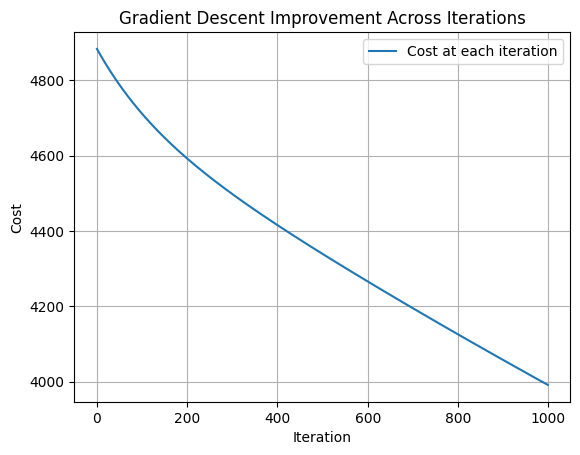

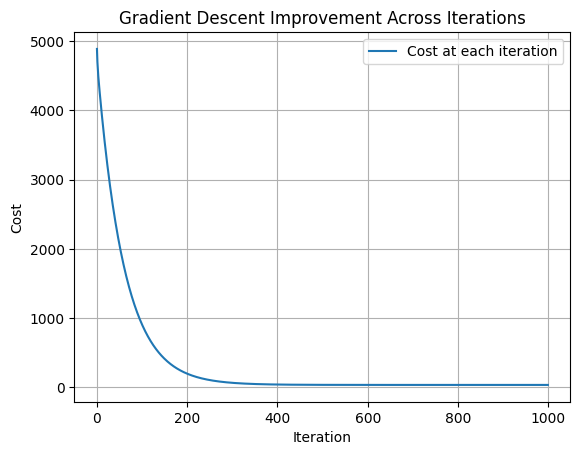

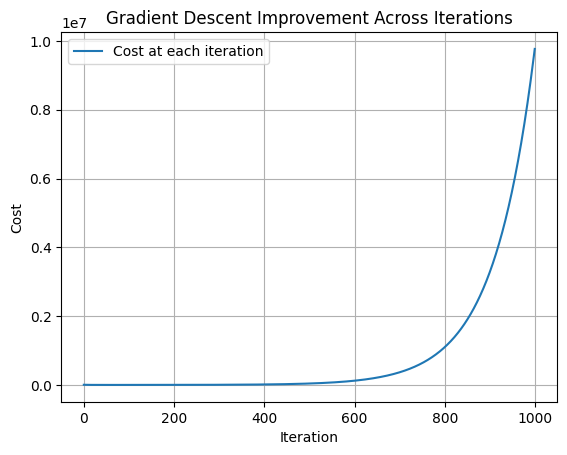

In [15]:
gradient_descent_with_plot(x_train, y_train, w_init, b_init, 0.001, iterations) # too slow
gradient_descent_with_plot(x_train, y_train, w_init, b_init, 0.1, iterations)   # just right
gradient_descent_with_plot(x_train, y_train, w_init, b_init, 0.505, iterations) # unstable



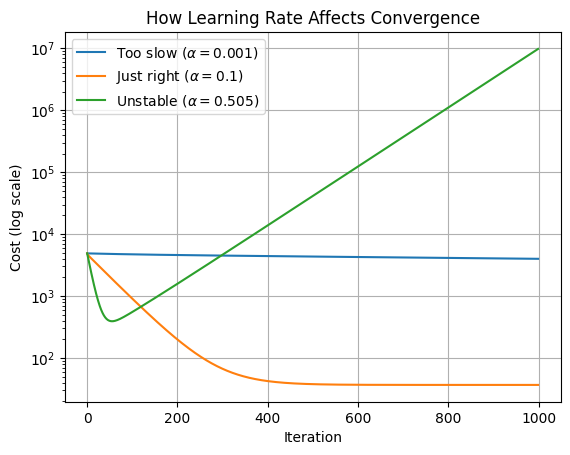

In [17]:
_, __, slow_costs = gradient_descent(x_train, y_train, w_init, b_init, 0.001, iterations) # too slow
_, __, good_costs = gradient_descent(x_train, y_train, w_init, b_init, 0.1, iterations)   # just right
_, __, unstable_costs = gradient_descent(x_train, y_train, w_init, b_init, 0.505, iterations)   # unstable

plt.plot(range(len(slow_costs)), slow_costs, label=r'Too slow ($\alpha=0.001$)')
plt.plot(range(len(good_costs)), good_costs, label=r'Just right ($\alpha=0.1$)')
plt.plot(range(len(unstable_costs)), unstable_costs, label=r'Unstable ($\alpha=0.505$)')
plt.title('How Learning Rate Affects Convergence')
plt.xlabel('Iteration')
plt.ylabel('Cost (log scale)')
plt.yscale('log')
plt.grid()
plt.legend()
plt.show()



### Q1 Why do we use a learning rate at all?

⭕️

We use a learning rate so that we can control and tune how quickly a model can
learn, balancing speed with stability.

### Q2 Why does the value of the learning rate matter?

⭕️

Too small of a learning rate and the model will take too minute of steps,
thereby taking forever to converge. Too large of a learning rate and the model
will be unstable and grow worse and worse.

## Final Fit Plot
Use your *best* learning rate choice and your trained $w$ and $b$.

Plot:
- the training data
- the final trained line
- the original poor fit line (w=0, b=400)
- a few middle lines showing the progression from poor fit to final fit

Make sure your legend includes the cost value for all lines.

⭕️⭕️⭕️⭕️⭕️

In [70]:
learning_rates = np.linspace(0.01, 0.5, 1000)
w_best = w_init
b_best = b_init
alpha_best = learning_rates[0]
J_best = float('inf')
for alpha in learning_rates:
  w, b, costs = gradient_descent(x_train, y_train, w_init, b_init, alpha, iterations)
  cost = costs[-1]
  if cost < J_best:
    w_best = w
    b_best = b
    alpha_best = alpha
    J_best = cost

print(f'best alpha: {alpha_best}')

best alpha: 0.2935035035035035


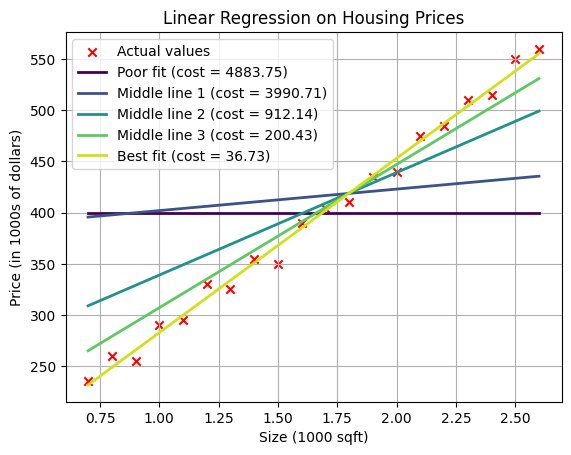

In [90]:
def add_to_plot(w, b, color, label):
  y_hat = compute_model_output(x_train, w, b)
  cost = mean_squared_error(y_train, y_hat)
  plt.plot(x_train, y_hat, c=color, label=f'{label} (cost = {cost:.2f})', linewidth=2)

mid_w_1, mid_b_1, _ = gradient_descent(x_train, y_train, w_init, b_init, 0.001, iterations)
mid_w_2, mid_b_2, _ = gradient_descent(x_train, y_train, w_init, b_init, 0.01, iterations)
mid_w_3, mid_b_3, _ = gradient_descent(x_train, y_train, w_init, b_init, 0.02, iterations)

plt.title("Linear Regression on Housing Prices")
plt.ylabel('Price (in 1000s of dollars)')
plt.xlabel('Size (1000 sqft)')
plt.scatter(x_train, y_train, c='red', marker='x', label='Actual values')
add_to_plot(poor_w, poor_b, '#440154', 'Poor fit')
add_to_plot(mid_w_1, mid_b_1, '#3b528b', 'Middle line 1')
add_to_plot(mid_w_2, mid_b_2, '#21918c', 'Middle line 2')
add_to_plot(mid_w_3, mid_b_3, '#5ec962', 'Middle line 3')
add_to_plot(w_best, b_best, '#d0e11c', 'Best fit')
plt.grid()
plt.legend()
plt.savefig('gradient_descent.png', dpi=1000)
plt.show()
